In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Kitti_Yolo_Tracking

Mounted at /content/drive
/content/drive/MyDrive/Kitti_Yolo_Tracking


# Install python libs (

In [5]:
!pip install ultralytics opencv-python matplotlib onnxruntime onnx onnxruntime-gpu pycuda onnxruntime-tools --quiet

In [2]:
# install torch for cuda support --> torch.cuda.is_available() returns true
!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvid

In [12]:
import torch
torch.cuda.is_available()
#!nvidia-smi # check if T4 is shown
# if this returns true. GPU is hidden and not assigned as 0
#torch.backends.cudnn.enabled

True

In [8]:
# install
!nvidia-smi

!pip install --upgrade pip
!pip install ultralytics onnx onnxruntime-gpu pycuda

Mon Mar 23 18:11:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             31W /   70W |     431MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# Install TensorRT system packages
!apt-get update
!apt-get install -y tensorrt

# Verify installation
!which trtexec
!trtexec --help | head -n 20

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,454 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,901 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-secu

# Get KITTI Dataset

In [ ]:
!python preprocessing/download_kittidataset.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Extracting data_object_image_2.zip...
Extracting data_object_label_2.zip...
KITTI dataset ready!


# Convert the Ground-truth label files ( KITTI -> YOLO) & Split dataset into train & val

In [5]:
!rm -rf "/content/drive/MyDrive/Kitti_Yolo_Tracking/kitti/testing"

In [ ]:
!python preprocessing/label_convertor.py "kitti2yolo"

KITTI -->  YOLO conversion complete!
Train images: 5984
Val images:   1497


# Trigger model training

In [ ]:
from ultralytics import YOLO

model = YOLO("model/yolov8n.pt")  # or yolov8s.pt
model.train(
        data="data/kitti.yaml",
        epochs=50,
        imgsz=640,
        batch=16,
    )

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=kitti.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

KeyboardInterrupt: 

# Generate mAP50 & mAP50-95 Metrics

In [ ]:
!python model/evaluate_yolo.py

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.3±3.8 ms, read: 47.4±6.3 MB/s, size: 804.6 KB)
val: Scanning /content/drive/MyDrive/kitti_yolo_project/Kitti_Yolo_Tracking/kitti_yolo/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1497/1497 139.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 2.1s/it 3:17
                   all       1497       6882      0.883      0.784      0.865      0.596
                   Car       1333       5680      0.928      0.906       0.96       0.78
            Pedestrian        357        896       0.88      0.671      0.795      0.441
               Cyclist        222        306      0.841      0.777      0.839      0.567
Speed: 1.4ms preprocess, 89.5ms inference, 0.0ms loss, 0.4ms postprocess per image


# Visualize Ground-truth label vs Predictions for the particular image

In [ ]:
!python utils/visualize_predictions.py


image 1/1 /content/drive/MyDrive/kitti_yolo_project/Kitti_Yolo_Tracking/kitti_yolo/images/val/000003.png: 224x640 2 Cars, 169.4ms
Speed: 7.6ms preprocess, 169.4ms inference, 1.7ms postprocess per image at shape (1, 3, 224, 640)
Figure(1600x800)


# Run YOLO predictions for sample video

In [ ]:
# load model
model = YOLO("runs/detect/train/weights/best.pt")

# run model on sample input video
result = model('results/sample2.mp4', save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/678) /content/drive/MyDrive/kitti_yolo_project/Kitti_Yolo_Tracking/results/sample2.mp4: 384x640 10 Pedestrians, 1 Cyclist, 300.8ms
video 1/1 (frame 2/678) /content/drive/MyDrive/kitti_yolo_project/Kitti_Yolo_Tracking/results/sample2.mp4: 384x640 8 Pedestrians, 1 Cyclist, 151.0ms
video 1/1 (frame 3/678) /content/drive/MyDrive/kitti_yolo_project/Kitti_Yolo_Tracking/results/sample2.mp4: 384x640 1 Car, 7 Pedestrians, 1 Cyclist, 155.5ms
vid

# Trigger Benchmarking
 - **FP32_CPU vs INT8_CPU**
 - **FP32_GPU vs FP16_GPU**


=== FP32 CPU Evaluation ===
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.7 ms, read: 250.4±59.9 MB/s, size: 810.8 KB)
val: Scanning /content/drive/MyDrive/Kitti_Yolo_Tracking/kitti_yolo/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1497/1497 448.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 1.2s/it 1:54
                   all       1497       6882      0.883      0.784      0.865      0.596
                   Car       1333       5680      0.928      0.906       0.96       0.78
            Pedestrian        357        896       0.88      0.671      0.795      0.441
               Cyclist        222        306      0.841      0.777      0.839      0.567
Speed: 0.5ms preprocess, 55.4ms inference, 0.0ms loss, 0.4ms postpro


=== INT8 Evaluation (ONNX Runtime) ===
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Loading runs/detect/train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 214.1±59.3 MB/s, size: 775.0 KB)
val: Scanning /content/drive/MyDrive/Kitti_Yolo_Tracking/kitti_yolo/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1497/1497 392.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1497/1497 6.5it/s 3:50
                   all       1497       6882      0.881      0.793      0.868      0.598
                   Car       1333       5680       0.92       0.91       0.96      0.778
            Pedestrian        357        896       0.86       0.68      0.795      0.445
               Cyclist        222        306    

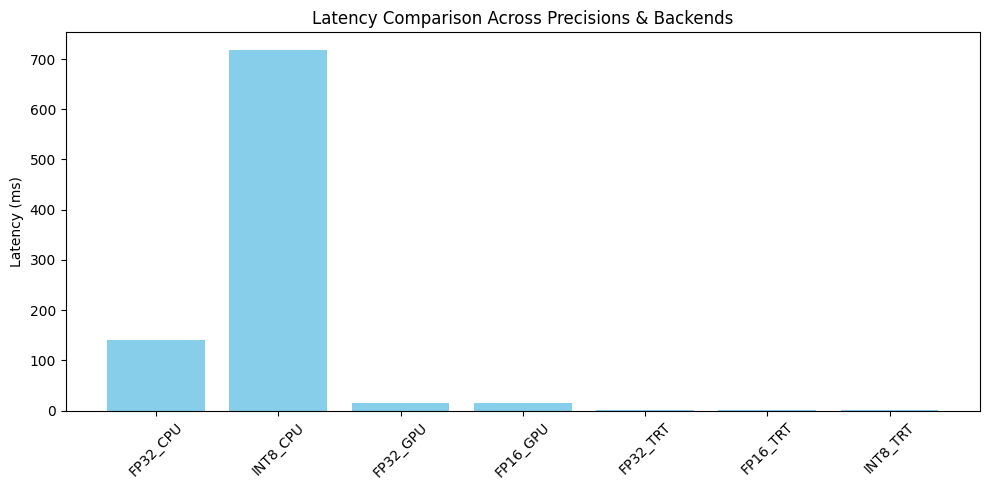

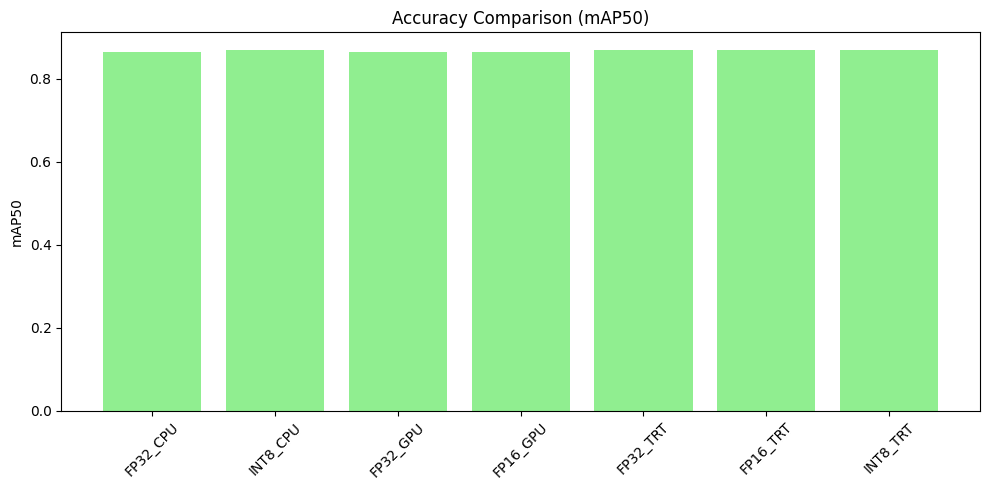

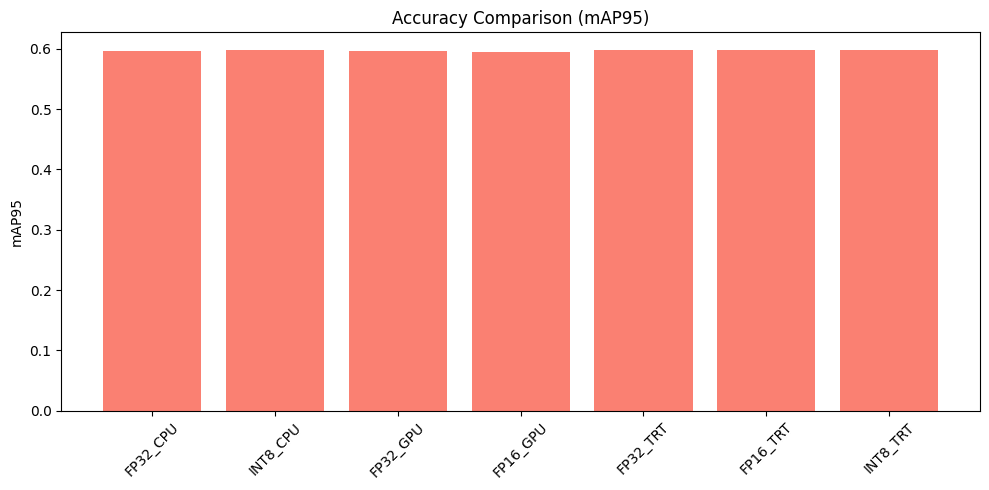

{'FP32_CPU': {'mAP50': np.float64(0.8647767764189959), 'mAP95': np.float64(0.5959262529691652), 'latency_ms': 140.42340517044067}, 'INT8_CPU': {'mAP50': np.float64(0.868245691602355), 'mAP95': np.float64(0.597591167674714), 'latency_ms': 717.2634959220886}, 'FP32_GPU': {'mAP50': np.float64(0.8647767764189959), 'mAP95': np.float64(0.5959262695797083), 'latency_ms': 14.290976524353027}, 'FP16_GPU': {'mAP50': np.float64(0.8646917355891864), 'mAP95': np.float64(0.5950279594674261), 'latency_ms': 15.158939361572266}, 'FP32_TRT': {'mAP50': np.float64(0.868245691602355), 'mAP95': np.float64(0.597591167674714), 'latency_ms': 0.3938150405883789}, 'FP16_TRT': {'mAP50': np.float64(0.868245691602355), 'mAP95': np.float64(0.597591167674714), 'latency_ms': 0.3990316390991211}, 'INT8_TRT': {'mAP50': np.float64(0.868245691602355), 'mAP95': np.float64(0.597591167674714), 'latency_ms': 0.4026174545288086}}


In [ ]:
from model.benchmark_model import trigger_all_benchmarks
trigger_all_benchmarks("runs/detect/train/weights/best.pt", "data/kitti.yaml")


# Generate prediction label files (YOLO format)

In [ ]:
results = model.predict(
    source="data/training/image_2",
    save_txt=True,     # saves YOLO-format predictions
    save_conf=True,    # include confidence scores
    project="runs/detect",
    name="predict",
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/7481 H:\GitHub\Kitti_Yolo_Tracking\data\training\image_2\000000.png: 224x640 1 Pedestrian, 162.7ms
image 2/7481 H:\GitHub\Kitti_Yolo_Tracking\data\training\image_2\000001.png: 224x640 1 Car, 1 Cyclist, 90.4ms
image 3/7481 H:\GitHub\Kitti_Yolo_Tracking\data\training\image_2\000002.png: 224x640 1 Car, 89.7ms
image 4/7481 H:\GitHub\Kitti_Yolo_Tracking\data\training\image_2\000003.png: 224x640 2 Cars, 86.3ms
image 5/7481 H:\GitHub\Kitti_Yolo_Tracking\da

# Convert prediction label files: YOLO -> KITTI

In [ ]:
!python preprocessing/label_convertor.py "yolo2kitti"

# Generate FAISS Vector index and document for summary store

In [ ]:
!python queries/generate_faiss_doc.py


Loading weights: 100%|##########| 103/103 [00:00<00:00, 1767.64it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.

Generating error documents: 100%|##########| 7481/7481 [00:05<00:00, 1395.46it/s]
